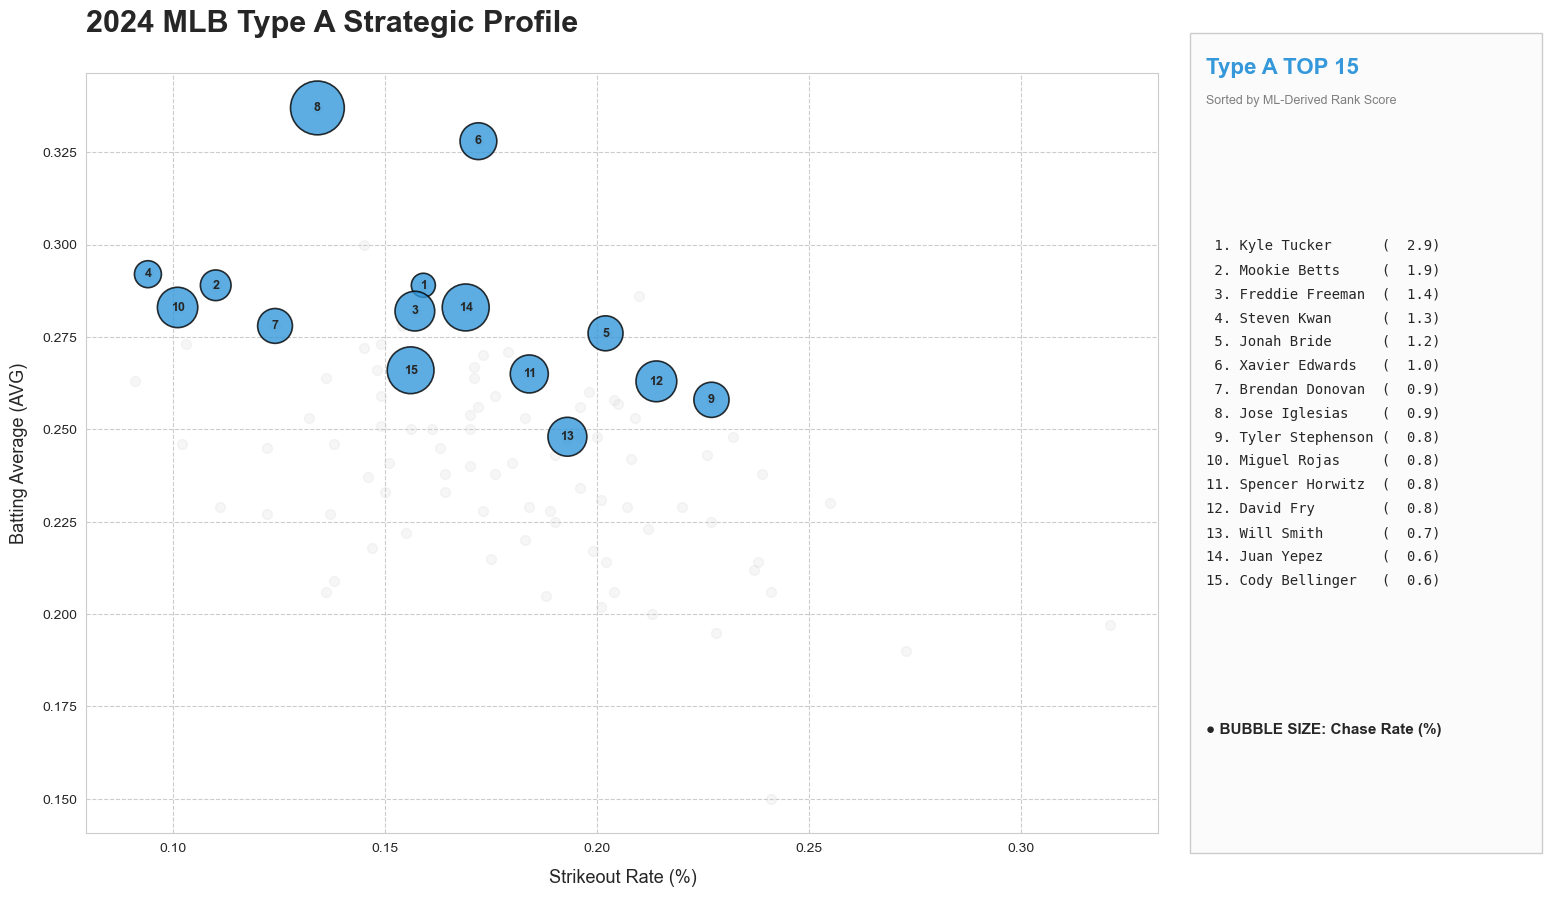

✅ Saved visualization for Type A: /Users/heounnyeong/Desktop/Personal_2/images/04_viz_type_a.png


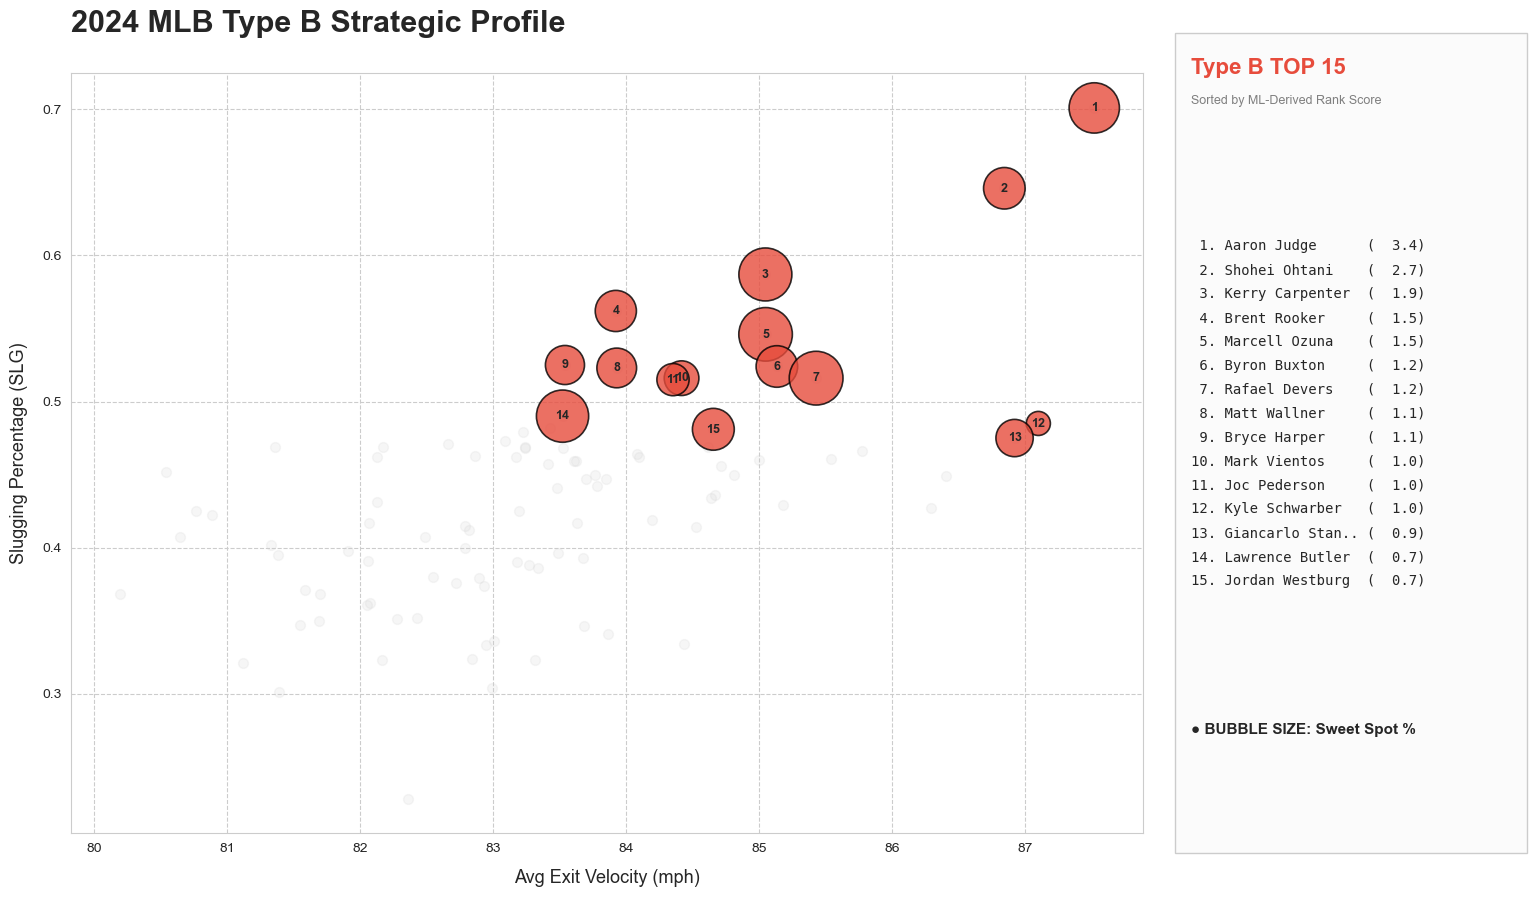

✅ Saved visualization for Type B: /Users/heounnyeong/Desktop/Personal_2/images/04_viz_type_b.png


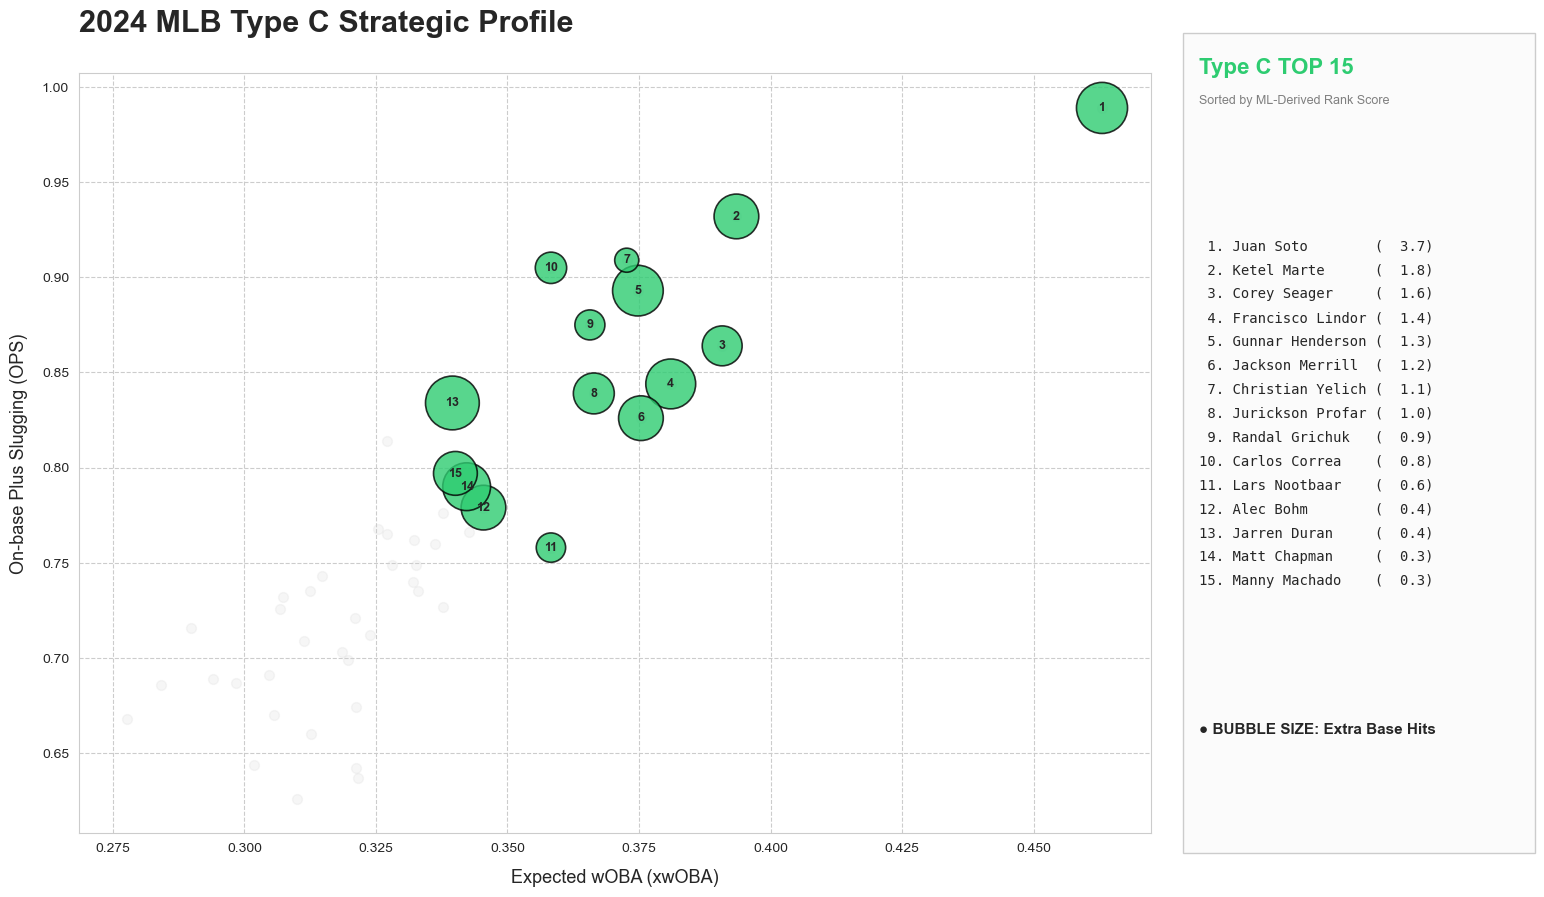

✅ Saved visualization for Type C: /Users/heounnyeong/Desktop/Personal_2/images/04_viz_type_c.png


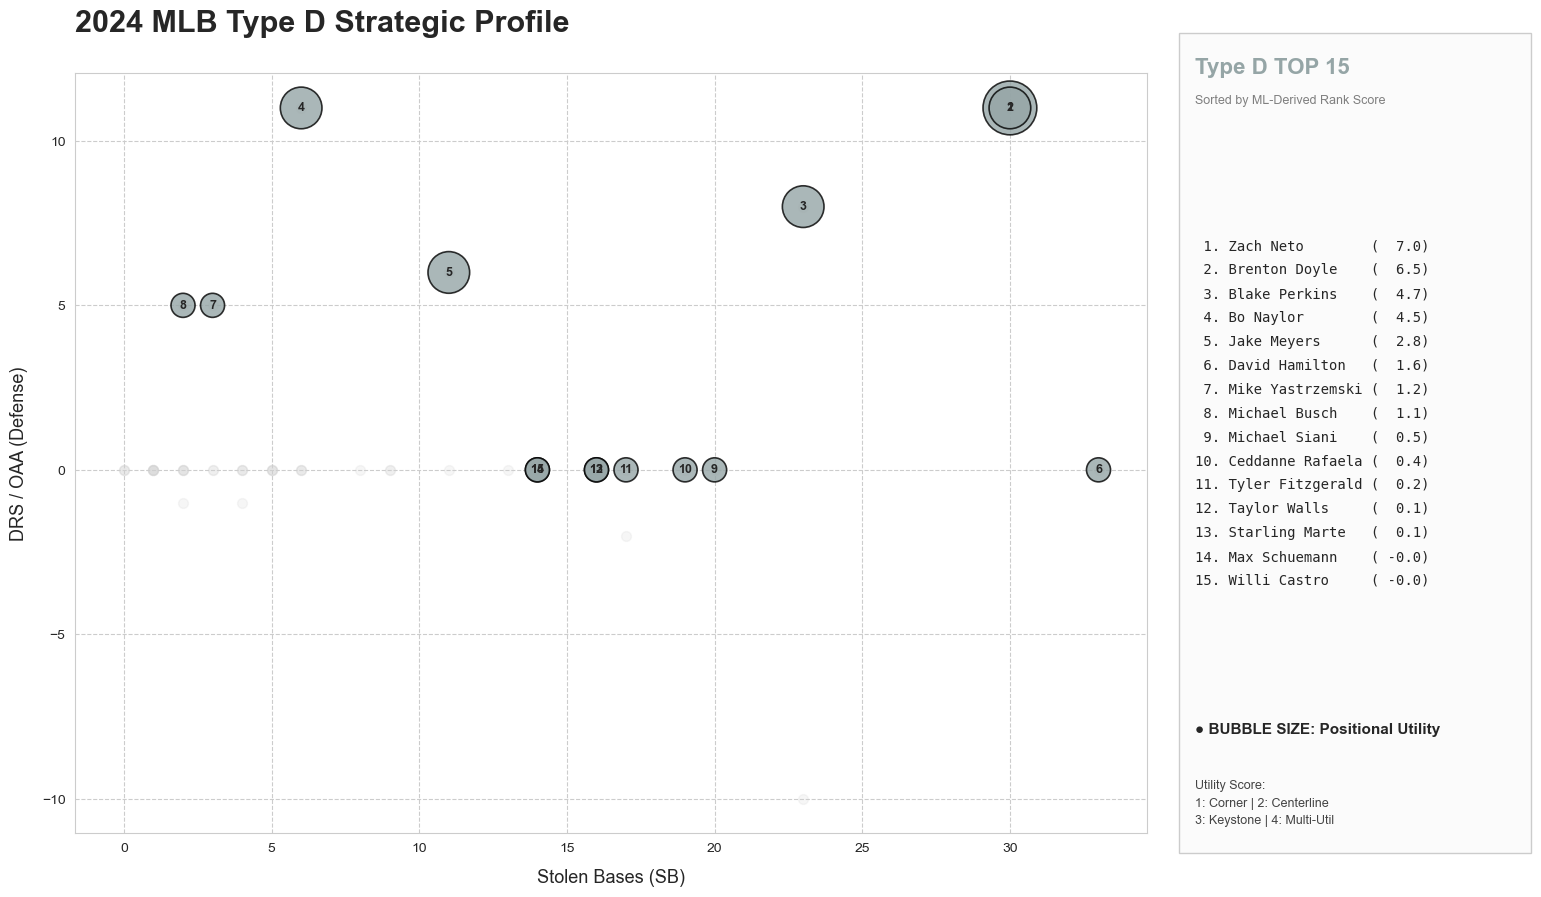

✅ Saved visualization for Type D: /Users/heounnyeong/Desktop/Personal_2/images/04_viz_type_d.png

🏁 Strategic Dashboard Generation Complete!
📍 Location: /Users/heounnyeong/Desktop/Personal_2/images/


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import os

# 1. Directory Setup
base_dir = os.path.dirname(os.getcwd()) 
input_path = os.path.join(base_dir, 'data', 'processed', 'hitter_final_results.csv')
image_save_dir = os.path.join(base_dir, 'images')

# Ensure image directory exists
os.makedirs(image_save_dir, exist_ok=True)

# 2. Load Final Results
if not os.path.exists(input_path):
    print(f"❌ Analysis file not found: {input_path}")
    print("Please run 03_feature_analysis.ipynb first.")
else:
    df = pd.read_csv(input_path)

    # ---------------------------------------------------------
    # 3. Dashboard Visualization Function
    # ---------------------------------------------------------
    def draw_type_specific_dashboard(target_type, x_axis, y_axis, size_axis, size_label, color_hex):
        """Generates a professional strategic map for each hitter type."""
        
        # Filter by type and sort by Rank Score (Top 15)
        type_df = df[df['hitter_type'] == target_type].copy()
        top_15 = type_df.sort_values('rank_score', ascending=False).head(15).reset_index(drop=True)
        
        if top_15.empty:
            print(f"⚠️ No data found for {target_type}. Skipping...")
            return

        # Setup figure and aesthetic style
        fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')
        sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.5})
        
        # 1) Background distribution (All players in the group)
        ax.scatter(type_df[x_axis], type_df[y_axis], c='lightgray', alpha=0.2, s=50, zorder=1)
        
        # 2) Highlight Top 15 (Bubble Chart)
        s_val = top_15[size_axis]
        # Normalize bubble sizes for visual consistency
        s_norm = (s_val - s_val.min()) / (s_val.max() - s_val.min() + 1e-9)
        bubble_sizes = s_norm * 1200 + 300
        
        scatter = ax.scatter(top_15[x_axis], top_15[y_axis], s=bubble_sizes, 
                             c=color_hex, alpha=0.8, edgecolors='black', linewidth=1.2, zorder=3)

        # 3) Labeling ranks inside bubbles
        for i, row in top_15.iterrows():
            ax.text(row[x_axis], row[y_axis], str(i+1), 
                    fontsize=9, ha='center', va='center', weight='bold', zorder=4)

        # ---------------------------------------------------------
        # 4. Sidebar Layout (Top 15 Leaderboard)
        # ---------------------------------------------------------
        # Background rectangle for the sidebar
        rect = Rectangle((0.76, 0.10), 0.22, 0.82, transform=fig.transFigure, 
                         facecolor='#FBFBFB', edgecolor='#CCCCCC', linewidth=1, zorder=0)
        fig.patches.append(rect)

        # Sidebar Title and Ranking List
        fig.text(0.77, 0.88, f"{target_type} TOP 15", fontsize=16, weight='bold', color=color_hex)
        fig.text(0.77, 0.85, "Sorted by ML-Derived Rank Score", fontsize=9, color='gray')
        
        list_lines = []
        for i, row in top_15.iterrows():
            raw_name = row['full_name']
            clean_name = raw_name if len(raw_name) <= 16 else raw_name[:14] + ".."
            line = f"{i+1:2d}. {clean_name:<16} ({row['rank_score']:>5.1f})"
            list_lines.append(line)

        fig.text(0.77, 0.54, "\n".join(list_lines), fontsize=10, family='monospace', va='center', linespacing=1.9)

        # Bubble Size Legend info
        fig.text(0.77, 0.22, f"● BUBBLE SIZE: {size_label}", fontsize=11, weight='bold')
        if target_type == 'Type D':
            fig.text(0.77, 0.13, "Utility Score:\n1: Corner | 2: Centerline\n3: Keystone | 4: Multi-Util", 
                     fontsize=9, color='#444444', linespacing=1.5)

        # 5. Axis Label Mapping
        label_map = {
            'k_pct': 'Strikeout Rate (%)', 'avg': 'Batting Average (AVG)', 
            'avg_ev': 'Avg Exit Velocity (mph)', 'slg': 'Slugging Percentage (SLG)',
            'xwoba': 'Expected wOBA (xwOBA)', 'ops': 'On-base Plus Slugging (OPS)',
            'sb': 'Stolen Bases (SB)', 'oaa': 'DRS / OAA (Defense)',
            'chase_pct': 'Chase Rate (%)', 'sweet_spot_pct': 'Sweet Spot %',
            'xbh': 'Extra Base Hits (XBH)', 'utility': 'Utility Score'
        }
        
        ax.set_title(f"2024 MLB {target_type} Strategic Profile", fontsize=22, weight='bold', loc='left', pad=30)
        ax.set_xlabel(label_map.get(x_axis, x_axis), fontsize=13, labelpad=10)
        ax.set_ylabel(label_map.get(y_axis, y_axis), fontsize=13, labelpad=10)

        # Adjust layout for the sidebar
        plt.subplots_adjust(left=0.07, right=0.74, top=0.88, bottom=0.12)
        
        # Save visualization
        save_name = f"04_viz_{target_type.lower().replace(' ', '_')}.png"
        save_path = os.path.join(image_save_dir, save_name)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved visualization for {target_type}: {save_path}")

    # ---------------------------------------------------------
    # 6. Dashboard Execution
    # ---------------------------------------------------------
    
    # Type A: Precision Hitters (K% vs AVG)
    draw_type_specific_dashboard('Type A', 'k_pct', 'avg', 'chase_pct', 'Chase Rate (%)', '#3498DB')

    # Type B: Power Hitters (EV vs SLG)
    draw_type_specific_dashboard('Type B', 'avg_ev', 'slg', 'sweet_spot_pct', 'Sweet Spot %', '#E74C3C')

    # Type C: Elite Hybrids (xwOBA vs OPS)
    draw_type_specific_dashboard('Type C', 'xwoba', 'ops', 'xbh', 'Extra Base Hits', '#2ECC71')

    # Type D: Role Players (SB vs OAA)
    draw_type_specific_dashboard('Type D', 'sb', 'oaa', 'utility', 'Positional Utility', '#95A5A6')

    print("\n" + "="*50)
    print("🏁 Strategic Dashboard Generation Complete!")
    print(f"📍 Location: {image_save_dir}/")
    print("="*50)